# Klasifikasi Lahan Sawah vs Pemukiman dengan Sentinel-2

**Tujuan:** membedakan area **sawah** dan **pemukiman** dari nilai band citra Sentinel-2 (L2A) pada 100 titik sampel (50 sawah + 50 pemukiman), menggunakan *machine learning* (supervised classification).

**Alur notebook:**
1. Memuat dan memahami data
2. Eksplorasi: statistik per kelas dan *spectral signature*
3. Pembersihan data (membuang titik berawan)
4. *Feature engineering*: indeks NDVI, NDWI, NDBI, MNDWI
5. Membagi data latih dan data uji
6. Melatih model dan membandingkan algoritma
7. Evaluasi: akurasi, Kappa, *confusion matrix*
8. Menyimpan model dan (opsional) menerapkannya ke citra TIF

**Data yang dibutuhkan:** file tabel hasil *Sample Raster Values* di QGIS (CSV atau TSV, misalnya `Desktop.csv`), berisi kolom `fid`, `label`, `kelas`, dan band B02, B03, B04, B08, B11, B12 (Raw / reflektansi 0-1). File tidak perlu satu folder dengan notebook: kamu **mengunggahnya langsung** lewat tombol upload di bagian 2.

**Bisa dijalankan di Google Colab maupun Jupyter Notebook.** Untuk Jupyter lokal, install dulu `ipywidgets` agar tombol upload muncul.

## 1. Import library dan pengaturan

Bagian ini memuat library, pengaturan, dan dua fungsi bantu untuk **mengunggah file** (otomatis menyesuaikan: Google Colab memakai `files.upload()`, Jupyter memakai tombol upload dari `ipywidgets`).

In [ ]:
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, cohen_kappa_score, classification_report,
                             ConfusionMatrixDisplay)

# ---- Pengaturan ----
FITUR_BAND = ["B02", "B03", "B04", "B08", "B11", "B12"]
BATAS_AWAN = 0.30                    # piksel dengan B02 (biru) di atas ini dianggap awan/haze
RANDOM_STATE = 42

# ---- Fungsi bantu: unggah & unduh file ----
try:
    from google.colab import files        # hanya ada di Google Colab
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

_widget_unggah = None
_hasil_colab = None

def tampilkan_unggah(ekstensi):
    '''Tampilkan tombol upload. Di Colab, file langsung diminta lewat dialog.'''
    global _widget_unggah, _hasil_colab
    if EN_COLAB:
        _hasil_colab = files.upload()
    else:
        try:
            import ipywidgets as widgets
            from IPython.display import display
        except ImportError:
            raise ImportError("Install dulu: pip install ipywidgets  (lalu restart kernel)")
        _widget_unggah = widgets.FileUpload(accept=ekstensi, multiple=False)
        display(_widget_unggah)
        print("Klik tombol 'Upload' di atas, pilih file, lalu jalankan sel berikutnya.")

def ambil_unggahan():
    '''Kembalikan (nama_file, isi_bytes) dari file yang baru diunggah.'''
    if EN_COLAB:
        if not _hasil_colab:
            raise ValueError("Belum ada file yang diunggah. Jalankan ulang sel unggah.")
        nama = next(iter(_hasil_colab))
        return nama, _hasil_colab[nama]
    if _widget_unggah is None or not _widget_unggah.value:
        raise ValueError("Belum ada file yang diunggah. Klik tombol Upload dulu.")
    v = _widget_unggah.value
    if isinstance(v, dict):                      # ipywidgets versi 7
        nama = next(iter(v)); return nama, v[nama]["content"]
    item = v[0]                                  # ipywidgets versi 8
    return item["name"], bytes(item["content"])

def unduh(nama_file):
    '''Di Colab, unduh file hasil ke komputer. Di Jupyter, file sudah tersimpan di folder kerja.'''
    if EN_COLAB:
        files.download(nama_file)
    else:
        print("Tersimpan di folder kerja notebook:", nama_file)

## 2. Mengunggah dan memuat data

**Langkah 1:** jalankan sel di bawah, lalu **unggah file tabel titik** kamu (misalnya `Desktop.csv`). Di Colab akan muncul dialog pilih file, di Jupyter akan muncul tombol *Upload*.

In [ ]:
tampilkan_unggah(".csv,.tsv,.txt")

Saving Desktop.csv to Desktop.csv


**Langkah 2:** setelah file terunggah, jalankan sel ini. File dari QGIS biasanya dipisah koma atau tab, dan nama kolom bandnya panjang (contoh: `2026-10-01-..._B04_(Raw)`). Kita baca file tersebut, menyederhanakan nama kolom menjadi `B02`, `B03`, dst, dan membuat kolom `y` (1 = sawah, 2 = pemukiman).

In [ ]:
nama_file, isi = ambil_unggahan()
print("File dibaca:", nama_file)

baris_pertama = isi.decode("utf-8", errors="ignore").splitlines()[0]
pemisah = "\t" if "\t" in baris_pertama else ","
df = pd.read_csv(io.BytesIO(isi), sep=pemisah)

# Sederhanakan nama kolom band
for b in FITUR_BAND:
    kolom_asli = [c for c in df.columns if re.search(rf"{b}(_|\b)", c) and "Raw" in c][0]
    df[b] = df[kolom_asli]

df["y"] = np.where(df["kelas"].str.strip().str.lower() == "sawah", 1, 2)
df = df[["fid", "label", "kelas", "y"] + FITUR_BAND]

print("Jumlah baris:", len(df))
df.head()

File dibaca: Desktop.csv
Jumlah baris: 100


,fid,label,kelas,y,B02,B03,B04,B08,B11,B12
0,1,Sawah1,Sawah,1,0.0475,0.0790,0.0611,0.3924,0.2442,0.1480
1,2,Sawah2,Sawah,1,0.0745,0.1263,0.1176,0.4105,0.2824,0.1942
2,3,Sawah3,Sawah,1,0.0873,0.1205,0.1766,0.2629,0.3561,0.3004
3,4,Sawah4,Sawah,1,0.0722,0.0984,0.1226,0.2691,0.3113,0.2415
4,5,Sawah5,Sawah,1,0.1037,0.1395,0.1788,0.3503,0.4005,0.3046


### Cek jumlah data per kelas

Pastikan jumlah sampel tiap kelas seimbang. Kalau sangat timpang, model cenderung condong ke kelas yang lebih banyak.

In [ ]:
df["kelas"].value_counts()

,count
kelas,
Sawah,50
Pemukiman,50


## 3. Eksplorasi data

### 3.1 Statistik tiap band per kelas

Rata-rata dan simpangan baku tiap band. Band yang rata-ratanya **berbeda jauh** antar kelas biasanya berguna untuk klasifikasi.

Perhatikan bahwa tabel ini **masih memuat titik berawan**, sehingga simpangan baku kelas pemukiman terlihat sangat besar (terutama B02, B03, B04). Titik tersebut dibuang di bagian 4.

In [ ]:
df.groupby("kelas")[FITUR_BAND].agg(["mean", "std"]).round(3)

B02           B03           B04           B08           B11  \
            mean    std   mean    std   mean    std   mean    std   mean   
kelas                                                                      
Pemukiman  0.182  0.256  0.199  0.212  0.224  0.181  0.347  0.133  0.411   
Sawah      0.076  0.020  0.110  0.022  0.116  0.046  0.331  0.063  0.308   

                    B12         
             std   mean    std  
kelas                           
Pemukiman  0.085  0.334  0.079  
Sawah      0.052  0.215  0.057

### 3.2 Spectral signature (kurva pantulan)

Grafik ini menunjukkan rata-rata pantulan tiap kelas pada tiap panjang gelombang. Pola kurvanya menjelaskan *mengapa* kelas bisa dibedakan: vegetasi sehat memantulkan kuat di NIR (B08), sedangkan bangunan dan tanah terbuka memantulkan lebih tinggi di SWIR (B11, B12).

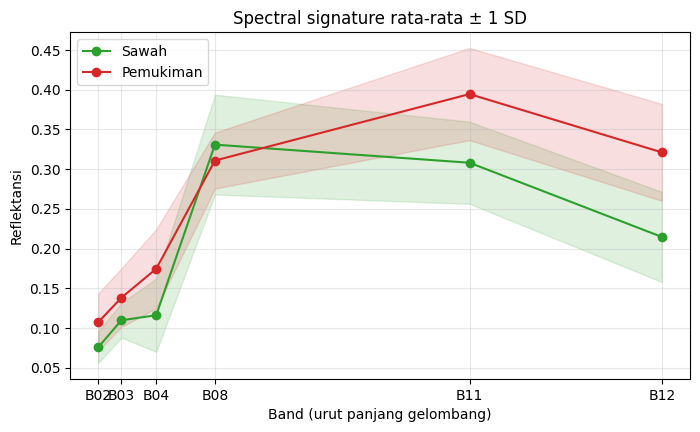

In [ ]:
panjang_gelombang = {"B02": 490, "B03": 560, "B04": 665, "B08": 842, "B11": 1610, "B12": 2190}  # nm
x = [panjang_gelombang[b] for b in FITUR_BAND]

plt.figure(figsize=(8, 4.5))
for kelas, warna in [("Sawah", "tab:green"), ("Pemukiman", "tab:red")]:
    sub = df[(df["kelas"] == kelas) & (df["B02"] <= BATAS_AWAN)]   # tanpa titik berawan
    rata, sd = sub[FITUR_BAND].mean().values, sub[FITUR_BAND].std().values
    plt.plot(x, rata, marker="o", color=warna, label=kelas)
    plt.fill_between(x, rata - sd, rata + sd, color=warna, alpha=0.15)
plt.xticks(x, FITUR_BAND)
plt.xlabel("Band (urut panjang gelombang)")
plt.ylabel("Reflektansi")
plt.title("Spectral signature rata-rata ± 1 SD")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 4. Pembersihan data: membuang titik berawan

Awan dan haze membuat nilai semua band melonjak, terutama band biru (B02). Titik seperti ini **bukan** mencerminkan permukaan lahan sehingga akan mengacaukan model. Kita buang titik dengan B02 di atas `BATAS_AWAN`.

In [ ]:
awan = df["B02"] > BATAS_AWAN
print("Titik terdeteksi awan:", df.loc[awan, "fid"].tolist())
df.loc[awan, ["fid", "label"] + FITUR_BAND].round(3)

Titik terdeteksi awan: [96, 97, 98, 99, 100]


,fid,label,B02,B03,B04,B08,B11,B12
95,96,Pemukiman46,0.541,0.478,0.428,0.499,0.464,0.356
96,97,Pemukiman47,0.370,0.340,0.326,0.414,0.420,0.320
97,98,Pemukiman48,0.936,0.796,0.724,0.708,0.592,0.480
98,99,Pemukiman49,1.408,1.229,1.095,1.040,0.781,0.649
99,100,Pemukiman50,1.003,0.873,0.792,0.687,0.544,0.453


In [ ]:
data = df[~awan].reset_index(drop=True)
print("Sisa data:", len(data), "titik")
print(data["kelas"].value_counts().to_string())

Sisa data: 95 titik
kelas
Sawah        50
Pemukiman    45


## 5. Feature engineering: indeks spektral

Selain band mentah, kita hitung indeks yang umum untuk memisahkan tutupan lahan:

| Indeks | Rumus | Fungsi |
|---|---|---|
| NDVI | (B08 - B04) / (B08 + B04) | Kehijauan vegetasi |
| NDWI | (B03 - B08) / (B03 + B08) | Kandungan air/vegetasi basah |
| NDBI | (B11 - B08) / (B11 + B08) | Area terbangun (bangunan) |
| MNDWI | (B03 - B11) / (B03 + B11) | Air (versi modifikasi) |

In [ ]:
eps = 1e-9
data["NDVI"]  = (data["B08"] - data["B04"]) / (data["B08"] + data["B04"] + eps)
data["NDWI"]  = (data["B03"] - data["B08"]) / (data["B03"] + data["B08"] + eps)
data["NDBI"]  = (data["B11"] - data["B08"]) / (data["B11"] + data["B08"] + eps)
data["MNDWI"] = (data["B03"] - data["B11"]) / (data["B03"] + data["B11"] + eps)

INDEKS = ["NDVI", "NDWI", "NDBI", "MNDWI"]
data.groupby("kelas")[INDEKS].agg(["mean", "std"]).round(3)

NDVI          NDWI          NDBI         MNDWI       
            mean    std   mean    std   mean    std   mean    std
kelas                                                            
Pemukiman  0.292  0.132 -0.392  0.101  0.116  0.071 -0.488  0.068
Sawah      0.478  0.189 -0.494  0.106 -0.032  0.136 -0.475  0.046

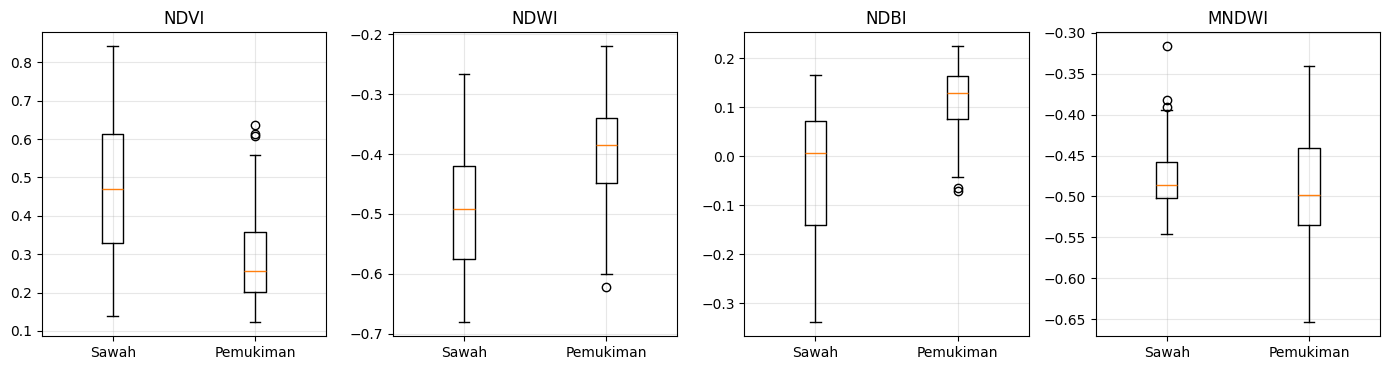

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, nama in zip(axes, INDEKS):
    ax.boxplot([data.loc[data["y"] == 1, nama], data.loc[data["y"] == 2, nama]])
    ax.set_xticks([1, 2]); ax.set_xticklabels(["Sawah", "Pemukiman"])
    ax.set_title(nama); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Cara membaca boxplot:** semakin sedikit tumpang tindih kotak antara dua kelas, semakin baik indeks itu memisahkan kelas. Kalau kotaknya banyak bertumpuk, indeks tersebut kurang membantu sendirian.

## 6. Membagi data latih dan data uji

Model harus diuji pada data yang **tidak pernah dilihat saat dilatih**, supaya kita tahu kemampuan generalisasinya. Data dibagi 70% latih dan 30% uji secara *stratified* (proporsi kelas tetap terjaga).

In [ ]:
FITUR = FITUR_BAND            # model utama: 6 band mentah
X = data[FITUR].values
y = data["y"].values

X_latih, X_uji, y_latih, y_uji, idx_latih, idx_uji = train_test_split(
    X, y, np.arange(len(data)), test_size=0.30, stratify=y, random_state=RANDOM_STATE)

print("Data latih:", len(y_latih), "| Data uji:", len(y_uji))

Data latih: 66 | Data uji: 29


## 7. Melatih model

Kita pakai **Logistic Regression** sebagai model utama. Fitur distandarkan dulu (`StandardScaler`) supaya band dengan skala berbeda diperlakukan setara. Dengan data yang kecil (kurang dari 100 titik), model sederhana seperti ini sering lebih stabil daripada model kompleks.

In [ ]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_latih, y_latih)
print("Model selesai dilatih.")

Model selesai dilatih.


## 8. Evaluasi pada data uji

- **Akurasi:** persentase prediksi yang benar.
- **Kappa:** akurasi yang sudah dikoreksi kebetulan (0 = sama dengan menebak acak, 1 = sempurna).
- **Confusion matrix:** menunjukkan kelas mana yang tertukar.
- **Precision / Recall / F1:** kualitas per kelas.

In [ ]:
y_pred = model.predict(X_uji)
print(f"Akurasi data uji : {accuracy_score(y_uji, y_pred):.3f}")
print(f"Kappa            : {cohen_kappa_score(y_uji, y_pred):.3f}\n")
print(classification_report(y_uji, y_pred, target_names=["sawah", "pemukiman"], digits=3))

Akurasi data uji : 0.793
Kappa            : 0.588

              precision    recall  f1-score   support

       sawah      0.846     0.733     0.786        15
   pemukiman      0.750     0.857     0.800        14

    accuracy                          0.793        29
   macro avg      0.798     0.795     0.793        29
weighted avg      0.800     0.793     0.793        29



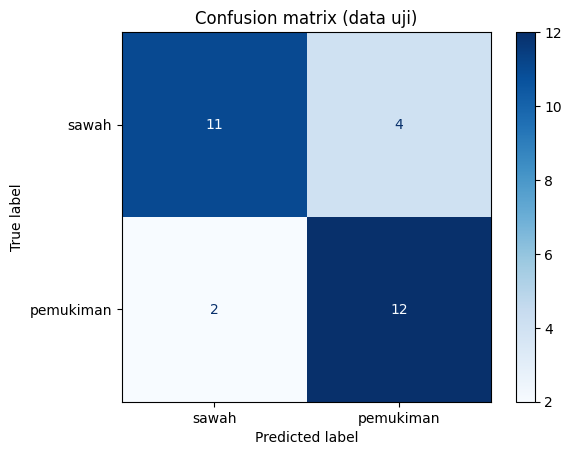

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_uji, y_pred, display_labels=["sawah", "pemukiman"], cmap="Blues")
plt.title("Confusion matrix (data uji)"); plt.show()

## 9. Validasi silang (cross-validation)

Dengan data uji hanya sekitar 29 titik, satu atau dua titik saja bisa menggeser akurasi cukup jauh. Karena itu kita lakukan **validasi silang 5-lipat yang diulang 10 kali**: data dibagi 5 bagian, bergantian tiap bagian jadi data uji, lalu diulang dengan pengacakan berbeda. Hasilnya lebih stabil dan layak dilaporkan.

Di sini sekaligus kita **bandingkan tiga algoritma** dan dua set fitur (band mentah vs band + indeks).

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

kandidat = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "SVM (RBF)":           make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0)),
}
set_fitur = {
    "6 band mentah": FITUR_BAND,
    "Band + indeks": FITUR_BAND + INDEKS,
}

hasil = []
for nama_f, kolom in set_fitur.items():
    for nama_m, m in kandidat.items():
        skor = cross_val_score(m, data[kolom].values, y, cv=cv, scoring="accuracy")
        hasil.append({"Fitur": nama_f, "Model": nama_m,
                      "Akurasi rata-rata": skor.mean(), "SD": skor.std()})

pd.DataFrame(hasil).sort_values("Akurasi rata-rata", ascending=False).round(3).reset_index(drop=True)

,Fitur,Model,Akurasi rata-rata,SD
0,6 band mentah,Logistic Regression,0.840,0.071
1,6 band mentah,SVM (RBF),0.827,0.079
2,Band + indeks,Logistic Regression,0.821,0.068
3,6 band mentah,Random Forest,0.814,0.082
4,Band + indeks,SVM (RBF),0.814,0.080
5,Band + indeks,Random Forest,0.792,0.085


**Cara membaca tabel:** ambil kombinasi dengan akurasi rata-rata tertinggi *dan* SD kecil. Kalau selisih antar kombinasi hanya 1-2 poin, anggap sama baiknya dan pilih yang paling sederhana.

## 10. Band mana yang paling berpengaruh?

Pada Logistic Regression dengan fitur terstandar, besar koefisien menunjukkan seberapa kuat suatu band mendorong prediksi. Koefisien **positif** mengarah ke **pemukiman**, **negatif** ke **sawah**.

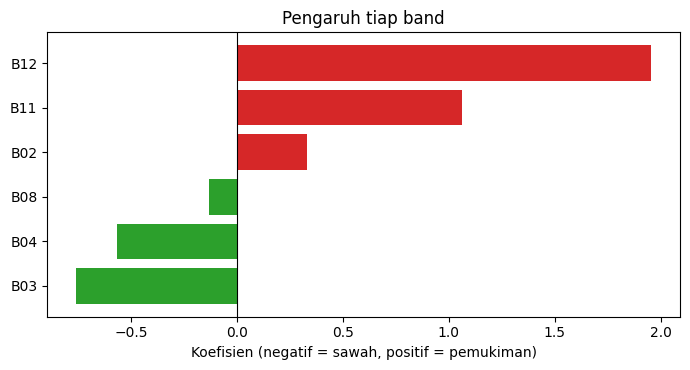

In [ ]:
koef = model.named_steps["logisticregression"].coef_[0]
urut = np.argsort(koef)

plt.figure(figsize=(7, 3.8))
plt.barh(np.array(FITUR)[urut], koef[urut],
         color=["tab:green" if k < 0 else "tab:red" for k in koef[urut]])
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("Koefisien (negatif = sawah, positif = pemukiman)")
plt.title("Pengaruh tiap band"); plt.tight_layout(); plt.show()

## 11. Melatih model final dan menyimpannya

Setelah yakin dengan konfigurasi, latih ulang model memakai **semua data** (lebih banyak data = model lebih baik), lalu simpan ke file agar bisa dipakai lagi tanpa melatih ulang.

In [ ]:
model_final = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model_final.fit(X, y)

joblib.dump({"model": model_final, "fitur": FITUR}, "model_sawah_pemukiman.joblib")
print("Model tersimpan: model_sawah_pemukiman.joblib")
unduh("model_sawah_pemukiman.joblib")

Model tersimpan: model_sawah_pemukiman.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Titik mana yang salah diprediksi?

Titik yang salah (khususnya dengan probabilitas tinggi) layak dicek manual di QGIS. Penyebabnya bisa label yang keliru, piksel campuran di tepi polygon, atau kondisi lahan yang memang mirip.

In [ ]:
prob = model_final.predict_proba(X)[:, 1]            # probabilitas pemukiman
hasil_titik = data[["fid", "label", "kelas", "y"]].copy()
hasil_titik["pred"] = model_final.predict(X)
hasil_titik["prob_pemukiman"] = prob.round(3)
salah = hasil_titik[hasil_titik["y"] != hasil_titik["pred"]]
print(f"Salah prediksi (pada data latih): {len(salah)} dari {len(data)} titik")
salah

Salah prediksi (pada data latih): 14 dari 95 titik


,fid,label,kelas,y,pred,prob_pemukiman
2,3,Sawah3,Sawah,1,2,0.636
4,5,Sawah5,Sawah,1,2,0.649
5,6,Sawah6,Sawah,1,2,0.744
7,8,Sawah8,Sawah,1,2,0.630
18,19,Sawah19,Sawah,1,2,0.700
21,22,Sawah22,Sawah,1,2,0.617
40,41,Sawah41,Sawah,1,2,0.601
50,51,Pemukiman1,Pemukiman,2,1,0.242
52,53,Pemukiman3,Pemukiman,2,1,0.462
53,54,Pemukiman4,Pemukiman,2,1,0.209


> Catatan: angka di atas dihitung pada data yang sama dengan data latih, jadi **bukan** ukuran akurasi sebenarnya. Pakai angka dari bagian 8 dan 9 untuk laporan.

## 12. (Opsional) Menerapkan model ke citra TIF

Kalau kamu sudah punya file TIF Sentinel-2 yang lengkap (10 m), model bisa dipakai untuk memprediksi **setiap piksel** dan menghasilkan peta klasifikasi. Bagian ini juga memakai unggah file, jadi TIF tidak perlu satu folder dengan notebook.

**Sebelum menjalankan, cek dua hal:**
1. `URUTAN_BAND_TIF`: urutan band pada TIF kamu (cek di QGIS: Properties > Information).
2. `SKALA_TIF`: gunakan `10000.0` kalau nilai TIF berupa DN 0-10000, atau `1.0` kalau sudah reflektansi 0-1.

Perlu library `rasterio` (`pip install rasterio`; di Colab jalankan `!pip install rasterio`). Kalau tidak ingin membuat peta, lewati bagian 12 ini dan langsung ke bagian 13.

**Langkah 1:** unggah file TIF.

In [ ]:
tampilkan_unggah(".tif,.tiff")

Saving sentinel2_6band.tif to sentinel2_6band.tif


**Langkah 2:** setelah TIF terunggah, jalankan sel ini untuk membuat peta klasifikasi.

TIF dibaca: sentinel2_6band.tif
Bentuk array: (6, 1258, 2106)


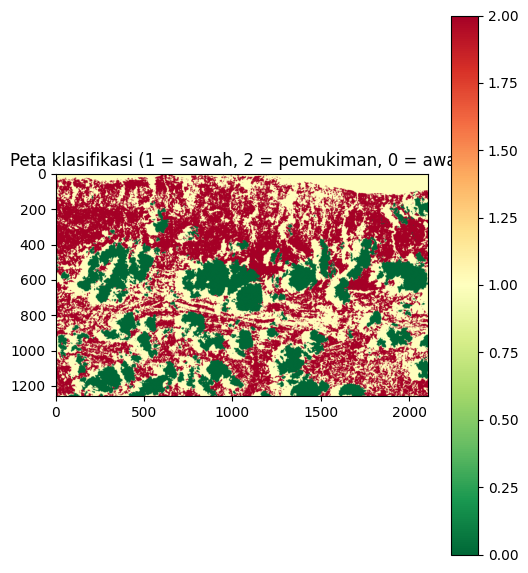

Piksel sawah: 1040960 | pemukiman: 1084586 | awan/kosong: 523802


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
URUTAN_BAND_TIF = ["B12", "B11", "B08", "B04", "B03", "B02"]
SKALA_TIF = 1.0

import numpy as np
import rasterio
import matplotlib.pyplot as plt

nama_tif, isi_tif = ambil_unggahan()
print("TIF dibaca:", nama_tif)

with rasterio.MemoryFile(isi_tif) as mf:
    with mf.open() as src:
        arr = src.read().astype("float32") / SKALA_TIF
        profil = src.profile

print("Bentuk array:", arr.shape)
if arr.shape[0] != len(URUTAN_BAND_TIF):
    raise ValueError(
        f"TIF ini hanya punya {arr.shape[0]} band, padahal dibutuhkan "
        f"{len(URUTAN_BAND_TIF)} band ({', '.join(URUTAN_BAND_TIF)}). "
        "Unduh ulang sebagai satu TIFF multi-band dengan urutan tersebut."
    )

idx = [URUTAN_BAND_TIF.index(b) for b in FITUR]
H, W = arr.shape[1:]
piksel = arr[idx].reshape(len(FITUR), -1).T

valid = np.isfinite(piksel).all(axis=1) & (piksel[:, FITUR.index("B02")] <= BATAS_AWAN)
hasil_peta = np.zeros(piksel.shape[0], dtype="uint8")        # 0 = awan / tidak diklasifikasi
hasil_peta[valid] = model_final.predict(piksel[valid])

profil.update(count=1, dtype="uint8", nodata=0)
with rasterio.open("peta_klasifikasi.tif", "w", **profil) as dst:
    dst.write(hasil_peta.reshape(H, W), 1)

plt.figure(figsize=(6, 7))
plt.imshow(hasil_peta.reshape(H, W), cmap="RdYlGn_r", vmin=0, vmax=2)
plt.title("Peta klasifikasi (1 = sawah, 2 = pemukiman, 0 = awan)")
plt.colorbar(); plt.show()

print(f"Piksel sawah: {(hasil_peta == 1).sum()} | pemukiman: {(hasil_peta == 2).sum()} | awan/kosong: {(hasil_peta == 0).sum()}")
unduh("peta_klasifikasi.tif")